In [1]:
# Cell 1: Imports
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Embedding, Dropout, add, # 'add' might be used for merging
    Concatenate, Reshape, GlobalAveragePooling2D, TimeDistributed,
    RepeatVector # Might be useful for image features
)
import matplotlib.pyplot as plt

In [2]:
# Cell 2: Define Directories
BASE_DIR = 'archive'
WORKING_DIR = 'results'
IMAGES_DIR = os.path.join(BASE_DIR, 'Images')
CAPTIONS_FILE = os.path.join(BASE_DIR, 'captions.txt')
FLATTENED_FEATURES_FILE = os.path.join(WORKING_DIR, 'features_4096.pkl') # New name for clarity
MODEL_PLOT_FILE = os.path.join(WORKING_DIR, 'cnn_lstm_model_plot.png')
SAVED_MODEL_FILE = os.path.join(WORKING_DIR, 'cnn_lstm_best_model.h5')
TRAINING_PLOT_FILE = os.path.join(WORKING_DIR, 'cnn_lstm_training_history_plot.png')

In [3]:
# Cell 3: Feature Extraction (Flattened 4096-dim vector)
def extract_flattened_features():
    vgg_model_full = VGG16()
    # Use the output of the second to last layer (before the final classification layer)
    feature_extractor = Model(inputs=vgg_model_full.inputs,
                              outputs=vgg_model_full.layers[-2].output)
    print(f"Feature extractor output shape: {feature_extractor.output_shape}") # Should be (None, 4096)

    extracted_features = {}
    if not os.path.exists(IMAGES_DIR):
        print(f"Error: Images directory not found at {IMAGES_DIR}")
        return None

    for img_name in tqdm(os.listdir(IMAGES_DIR)):
        img_path = os.path.join(IMAGES_DIR, img_name)
        try:
            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image)
            image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
            image = preprocess_input(image)
            feature = feature_extractor.predict(image, verbose=0) # Shape (1, 4096)
            image_id = img_name.split('.')[0]
            extracted_features[image_id] = feature # Store the (1, 4096) feature
        except Exception as e:
            print(f"Error processing image {img_name}: {e}")

    with open(FLATTENED_FEATURES_FILE, 'wb') as f:
        pickle.dump(extracted_features, f)
    print(f"Flattened features extracted and saved to {FLATTENED_FEATURES_FILE}")
    return extracted_features

# Load or extract features
if os.path.exists(FLATTENED_FEATURES_FILE):
    with open(FLATTENED_FEATURES_FILE, 'rb') as f:
        features = pickle.load(f)
    print(f"Loaded {len(features)} flattened features from {FLATTENED_FEATURES_FILE}")
else:
    print("Flattened features file not found. Running extraction...")
    features = extract_flattened_features()
    if features is None:
        raise ValueError("Feature extraction failed. Please check paths and images.")

Flattened features file not found. Running extraction...
Feature extractor output shape: (None, 4096)


  0%|          | 0/8091 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Flattened features extracted and saved to results/features_4096.pkl


In [4]:
# Cell 4: Load and Preprocess Captions (Same as before)
def load_caption_data(filename):
    mapping_dict = {}
    if not os.path.exists(filename):
        print(f"Error: Captions file not found at {filename}")
        return mapping_dict
        
    with open(filename, 'r') as f:
        next(f)
        doc = f.read()

    for line in tqdm(doc.split('\n')):
        tokens = line.split(',')
        if len(line) < 2 or len(tokens) < 2:
            continue
        image_id, caption_parts = tokens[0], tokens[1:]
        image_id = image_id.split('.')[0]
        caption = " ".join(caption_parts).strip()
        if image_id not in mapping_dict:
            mapping_dict[image_id] = []
        mapping_dict[image_id].append(caption)
    return mapping_dict

mapping = load_caption_data(CAPTIONS_FILE)
print(f"Original captions loaded for {len(mapping)} images.")

def clean_captions(mapping_to_clean):
    for key, captions_list in mapping_to_clean.items():
        for i in range(len(captions_list)):
            caption = captions_list[i]
            caption = caption.lower()
            caption = ''.join(filter(lambda x: x.isalpha() or x.isspace(), caption))
            caption = ' '.join(caption.split())
            caption = 'startseq ' + ' '.join([word for word in caption.split() if len(word) > 1]) + ' endseq'
            captions_list[i] = caption

clean_captions(mapping)

all_captions = []
for key in mapping:
    if key in features:
        for caption in mapping[key]:
            all_captions.append(caption)
print(f"Total captions after cleaning (for images with features): {len(all_captions)}")
if all_captions:
    print(f"Example cleaned caption: {all_captions[0]}")

  0%|          | 0/40456 [00:00<?, ?it/s]

Original captions loaded for 8091 images.
Total captions after cleaning (for images with features): 40455
Example cleaned caption: startseq child in pink dress is climbing up set of stairs in an entry way endseq


In [5]:
# Cell 5: Tokenizer and Vocabulary (Same as before)
tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in all_captions) # This is max_caption_length including start/end
print(f"Vocabulary Size: {vocab_size}")
print(f"Maximum caption length: {max_length}")

word_to_idx = tokenizer.word_index
idx_to_word_map = {idx: word for word, idx in word_to_idx.items()}

Vocabulary Size: 8769
Maximum caption length: 34


In [6]:
# Cell 6: Data Splitting (70/15/15) (Same as before)
image_ids_with_features = [img_id for img_id in mapping.keys() if img_id in features]
np.random.shuffle(image_ids_with_features)

train_split_idx = int(len(image_ids_with_features) * 0.70)
val_split_idx = int(len(image_ids_with_features) * (0.70 + 0.15))

train_ids = image_ids_with_features[:train_split_idx]
val_ids = image_ids_with_features[train_split_idx:val_split_idx]
test_ids = image_ids_with_features[val_split_idx:]

print(f"Total images with features & captions: {len(image_ids_with_features)}")
print(f"Training images: {len(train_ids)}")
print(f"Validation images: {len(val_ids)}")
print(f"Test images: {len(test_ids)}")

Total images with features & captions: 8091
Training images: 5663
Validation images: 1214
Test images: 1214


In [7]:
# Cell 7: Data Generator (Seq2Seq version, adjusted for flattened features)
def data_generator_seq2seq(data_keys, current_mapping, current_features, tokenizer_obj, max_cap_length, vocab_sz, batch_sz):
    X1_img_batch, X2_seq_batch, y_seq_batch = list(), list(), list()
    n_samples = 0
    while True:
        for key in data_keys:
            if key not in current_mapping or key not in current_features:
                continue
            
            captions = current_mapping[key]
            # current_features[key] is (1, 4096), so access [0]
            img_feature = current_features[key][0] # Shape: (4096,)

            for caption in captions:
                seq = tokenizer_obj.texts_to_sequences([caption])[0]
                if len(seq) < 2: continue

                input_text_seq_tokens = seq[:-1]
                output_text_seq_tokens = seq[1:]

                input_text_seq_padded = pad_sequences([input_text_seq_tokens], maxlen=max_cap_length, padding='post', truncating='post')[0]
                output_text_seq_padded = pad_sequences([output_text_seq_tokens], maxlen=max_cap_length, padding='post', truncating='post')[0]
                output_text_seq_categorical = to_categorical(output_text_seq_padded, num_classes=vocab_sz)

                X1_img_batch.append(img_feature)
                X2_seq_batch.append(input_text_seq_padded)
                y_seq_batch.append(output_text_seq_categorical)
                n_samples += 1

                if n_samples == batch_sz:
                    yield ((np.array(X1_img_batch), np.array(X2_seq_batch)), np.array(y_seq_batch))
                    X1_img_batch, X2_seq_batch, y_seq_batch = list(), list(), list()
                    n_samples = 0

In [8]:
# Cell 8: Model Definition (CNN+LSTM, no explicit attention, sequence-to-sequence)
embedding_dim = 256
lstm_units = 256
image_feature_dim_flat = 4096 # From VGG16 features.layers[-2]

# Image feature input
image_input_layer = Input(shape=(image_feature_dim_flat,), name="image_input_flat") # (None, 4096)

# Text input
text_input_layer = Input(shape=(max_length,), name="text_input") # (None, max_caption_length)

# Process image features to get initial LSTM states
# Dense layer to project image features to LSTM state size
initial_h_dense = Dense(lstm_units, activation='tanh', name="initial_h_dense")(image_input_layer)
initial_c_dense = Dense(lstm_units, activation='tanh', name="initial_c_dense")(image_input_layer)

# Embedding layer for text
embedding_output = Embedding(vocab_size, embedding_dim, mask_zero=True, name="embedding")(text_input_layer)

# LSTM decoder
# For inference, this LSTM layer must have return_state=True
decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name="decoder_lstm")
# Pass initial_state derived from image features
# The LSTM will output the full sequence of hidden states, and the final h and c states
lstm_output_sequence, _, _ = decoder_lstm(embedding_output, initial_state=[initial_h_dense, initial_c_dense])
# We use lstm_output_sequence for prediction at each time step.

# Output layers (TimeDistributed because LSTM returns sequences)
# Project LSTM outputs to vocab size
output_dense1 = TimeDistributed(Dense(256, activation='relu'), name="output_dense_1")(lstm_output_sequence)
output_dropout = TimeDistributed(Dropout(0.4), name="output_dropout")(output_dense1) # Project requirement
final_output_layer = TimeDistributed(Dense(vocab_size, activation='softmax'), name="final_output_softmax")(output_dropout)

model = Model(inputs=[image_input_layer, text_input_layer], outputs=final_output_layer)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()
try:
    plot_model(model, to_file=MODEL_PLOT_FILE, show_shapes=True, show_layer_activations=True)
    print(f"Model plot saved to {MODEL_PLOT_FILE}")
except Exception as e:
    print(f"Could not plot model: {e}. Ensure pydot and graphviz are installed.")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input_flat    │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  2,244,864 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_h_dense     │ (None, 256)       │  1,048,832 │ image_input_flat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ initial_c_dense     │ (None, 256)       │  1,048,832 │ image_input_flat… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 34, 256), │    525,312 │ embedding[0][0],  │
│                     │ (None, 256),      │            │ initial_h_dense[… │
│                     │ (None, 256)]      │            │ initial_c_dense[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense_1      │ (None, 34, 256)   │     65,792 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dropout      │ (None, 34, 256)   │          0 │ output_dense_1[0… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output_softm… │ (None, 34, 8769)  │  2,253,633 │ output_dropout[0… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,187,265 (27.42 MB)

 Trainable params: 7,187,265 (27.42 MB)

 Non-trainable params: 0 (0.00 B)

Model plot saved to results/cnn_lstm_model_plot.png


Starting training: epochs=20, batch_size=32, steps_train=884, steps_val=189
Epoch 1/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 155s 174ms/step - accuracy: 0.0474 - loss: 5.5039 - val_accuracy: 0.0747 - val_loss: 4.3254
Epoch 2/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 156s 176ms/step - accuracy: 0.0754 - loss: 4.2542 - val_accuracy: 0.0807 - val_loss: 4.0526
Epoch 3/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 157s 178ms/step - accuracy: 0.0826 - loss: 3.9433 - val_accuracy: 0.0862 - val_loss: 3.8873
Epoch 4/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 151s 171ms/step - accuracy: 0.0877 - loss: 3.7263 - val_accuracy: 0.0889 - val_loss: 3.7955
Epoch 5/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 153s 174ms/step - accuracy: 0.0907 - loss: 3.5681 - val_accuracy: 0.0904 - val_loss: 3.7395
Epoch 6/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 150s 170ms/step - accuracy: 0.0939 - loss: 3.4377 - val_accuracy: 0.0927 - val_loss: 3.7030
Epoch 7/20
884/884 ━━━━━━━━━━━━━━━━━━━━ 153s 173ms/step - accuracy: 0.0967 - loss: 3.3193 - val_accuracy: 0.0931 - val_loss: 3.6912


Model training complete and saved to results/cnn_lstm_best_model.h5.


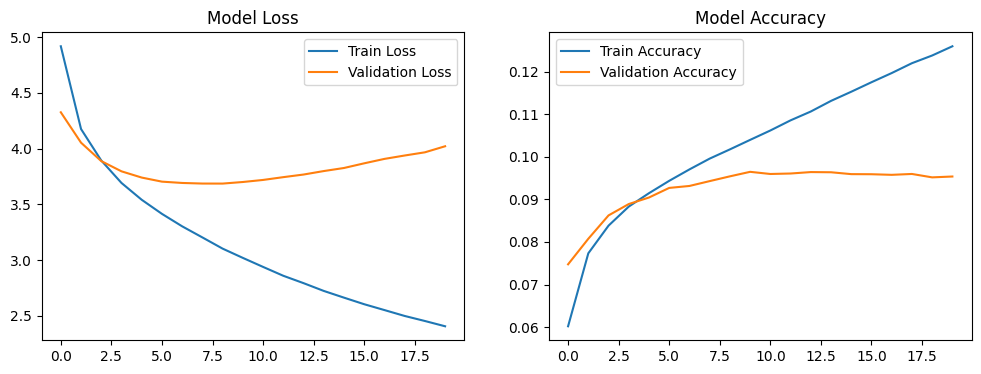

In [9]:
# Cell 9: Model Training (Adjusted output_signature for flattened features)
epochs = 20
batch_size = 32

output_signature_seq2seq = (
    (tf.TensorSpec(shape=(None, image_feature_dim_flat), dtype=tf.float32, name="image_features_flat"), # Changed shape
     tf.TensorSpec(shape=(None, max_length), dtype=tf.int32, name="text_sequence_input")),
    tf.TensorSpec(shape=(None, max_length, vocab_size), dtype=tf.float32, name="target_sequence_output")
)

train_keys_usable = [k for k in train_ids if k in features and k in mapping]
val_keys_usable = [k for k in val_ids if k in features and k in mapping]

num_train_samples = sum(len(mapping[k]) for k in train_keys_usable if k in mapping)
num_val_samples = sum(len(mapping[k]) for k in val_keys_usable if k in mapping)

steps_train = num_train_samples // batch_size
steps_val = num_val_samples // batch_size

train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_seq2seq(train_keys_usable, mapping, features, tokenizer, max_length, vocab_size, batch_size),
    output_signature=output_signature_seq2seq
).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_seq2seq(val_keys_usable, mapping, features, tokenizer, max_length, vocab_size, batch_size),
    output_signature=output_signature_seq2seq
).prefetch(tf.data.AUTOTUNE)

if steps_train == 0 or steps_val == 0:
    print(f"Warning: Not enough data. steps_train: {steps_train}, steps_val: {steps_val}.")
else:
    print(f"Starting training: epochs={epochs}, batch_size={batch_size}, steps_train={steps_train}, steps_val={steps_val}")
    history = model.fit(
        train_dataset,
        epochs=epochs,
        steps_per_epoch=steps_train,
        validation_data=val_dataset,
        validation_steps=steps_val,
        verbose=1
    )
    model.save(SAVED_MODEL_FILE)
    print(f"Model training complete and saved to {SAVED_MODEL_FILE}.")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.legend()
    plt.savefig(TRAINING_PLOT_FILE)
    plt.show()

In [11]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Lambda # Add Lambda here
# Cell 10: Inference Models and Prediction Function (Simpler, no attention)

# Encoder Model (extracts image features and initial LSTM states from them)
encoder_model_inf = Model(inputs=image_input_layer, outputs=[initial_h_dense, initial_c_dense])

# Decoder Model for single step prediction
decoder_input_h_inf = Input(shape=(lstm_units,), name="decoder_input_h_inf")
decoder_input_c_inf = Input(shape=(lstm_units,), name="decoder_input_c_inf")
decoder_input_text_step_inf = Input(shape=(1,), name="decoder_input_text_step_inf") # Single token input

# Get layers from the trained model
embedding_layer_inf = model.get_layer("embedding")
decoder_lstm_inf = model.get_layer("decoder_lstm") # This LSTM must have return_state=True
output_dense_1_inf = model.get_layer("output_dense_1").layer # Get the actual Dense layer
output_dropout_inf = model.get_layer("output_dropout").layer # Get the actual Dropout layer
final_output_softmax_inf = model.get_layer("final_output_softmax").layer # Get the actual Dense layer

# Decoder step execution
embedded_text_step_inf = embedding_layer_inf(decoder_input_text_step_inf) # (None, 1, embedding_dim)

# Pass current states to LSTM
lstm_out_step, next_h_state, next_c_state = decoder_lstm_inf(
    embedded_text_step_inf, initial_state=[decoder_input_h_inf, decoder_input_c_inf]
) # lstm_out_step is (None, 1, lstm_units)

dense1_out_step = output_dense_1_inf(lstm_out_step) # (None, 1, 256)
# Dropout is typically not applied during inference, or set to training=False
# For this setup, directly using the output of dense1 for the final softmax layer
# is common if dropout layer instance is not called with training=False
final_pred_probs_step = final_output_softmax_inf(dense1_out_step) # (None, 1, vocab_size)
final_pred_probs_step = Lambda(lambda x: tf.squeeze(x, axis=1), name="squeeze_final_pred")(final_pred_probs_step) # (None, vocab_size)
decoder_model_inf = Model(
    inputs=[decoder_input_text_step_inf, decoder_input_h_inf, decoder_input_c_inf],
    outputs=[final_pred_probs_step, next_h_state, next_c_state]
)
print("Inference encoder and decoder models (CNN+LSTM without explicit attention) created.")

def predict_caption_simple_lstm(image_id_to_predict, features_dict, enc_model, dec_model, tokenizer_obj, max_cap_len, idx_to_word_mapping_dict):
    if image_id_to_predict not in features_dict:
        print(f"Error: Features for image {image_id_to_predict} not found.")
        return "Error: Image features not found."

    img_feature_vgg = features_dict[image_id_to_predict] # Shape (1, 4096)

    # Get initial LSTM states from image features
    h_state, c_state = enc_model.predict(img_feature_vgg, verbose=0)

    predicted_sequence_words = []
    current_word_token_idx = np.array([[tokenizer_obj.word_index['startseq']]]) # Shape (1,1)

    for _ in range(max_cap_len):
        next_word_probs, h_state, c_state = dec_model.predict(
            [current_word_token_idx, h_state, c_state], verbose=0
        )
        
        predicted_word_idx = np.argmax(next_word_probs[0])
        word = idx_to_word_mapping_dict.get(predicted_word_idx, "<unk>")
        
        if word == 'endseq' or word == '<unk>':
            break
        predicted_sequence_words.append(word)
        current_word_token_idx = np.array([[predicted_word_idx]])

    return 'startseq ' + ' '.join(predicted_sequence_words) + ' endseq'

Inference encoder and decoder models (CNN+LSTM without explicit attention) created.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/layer.py:940: UserWarning: Layer 'squeeze_final_pred' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [12]:
# Cell 11: BLEU Score Evaluation (Using updated predict function)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

actual_captions_list, predicted_captions_list = [], []
test_keys_usable = [k for k in test_ids if k in features and k in mapping]

print(f"Evaluating on {len(test_keys_usable)} test images (CNN+LSTM without explicit attention)...")
if not test_keys_usable:
    print("No usable test keys found for evaluation.")
else:
    for key in tqdm(test_keys_usable):
        actual_img_captions_text = mapping[key]
        predicted_caption = predict_caption_simple_lstm(key, features, encoder_model_inf, decoder_model_inf, tokenizer, max_length, idx_to_word_map)
        
        actual_captions_split = [cap.split() for cap in actual_img_captions_text]
        predicted_caption_split = predicted_caption.split()
        
        actual_captions_list.append(actual_captions_split)
        predicted_captions_list.append(predicted_caption_split)

if actual_captions_list:
    chencherry = SmoothingFunction()
    bleu1 = corpus_bleu(actual_captions_list, predicted_captions_list, weights=(1.0, 0, 0, 0), smoothing_function=chencherry.method1)
    bleu2 = corpus_bleu(actual_captions_list, predicted_captions_list, weights=(0.5, 0.5, 0, 0), smoothing_function=chencherry.method1)
    bleu3 = corpus_bleu(actual_captions_list, predicted_captions_list, weights=(0.33, 0.33, 0.33, 0), smoothing_function=chencherry.method1)
    bleu4 = corpus_bleu(actual_captions_list, predicted_captions_list, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=chencherry.method1)

    print(f"BLEU-1: {bleu1*100:.2f}")
    print(f"BLEU-2: {bleu2*100:.2f}")
    print(f"BLEU-3: {bleu3*100:.2f}")
    print(f"BLEU-4: {bleu4*100:.2f}")
else:
    print("No captions generated to evaluate BLEU scores.")

Evaluating on 1214 test images (CNN+LSTM without explicit attention)...


  0%|          | 0/1214 [00:00<?, ?it/s]

BLEU-1: 55.36
BLEU-2: 32.64
BLEU-3: 20.95
BLEU-4: 12.75



Visualizing some results...

--- Image: 2071309418_1d7580b0f0.jpg ---
--- Actual Captions ---
startseq white dog wearing christmas reindeer headband plays with brown dog in the grass among some stuffed animals endseq
startseq white dog wearing reindeer ears is next to brown dog endseq
startseq white dog with fake antlers on its head and brown dog play together outdoors endseq
startseq the white dog next to the brown dog is wearing christmas headband endseq
startseq two dogs one wearing christmas antlers tussle on the grass endseq
--- Predicted Caption ---
startseq brown dog is running through the grass endseq


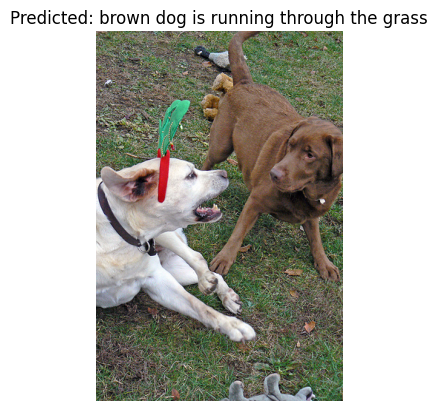


--- Image: 244870123_dcb6e53643.jpg ---
--- Actual Captions ---
startseq two dogs are tugging at piece of white material endseq
startseq two dogs fight over piece of cloth endseq
startseq two dogs tug on towel endseq
startseq two dogs with rag in their mouths endseq
startseq two large black dogs with red studded collars pulling on ends of white rag on porch endseq
--- Predicted Caption ---
startseq brown dog is running through the snow endseq


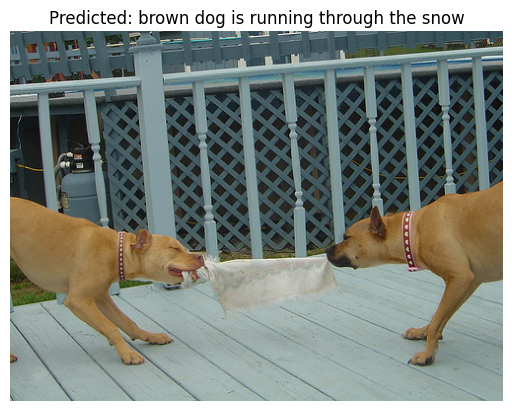


--- Image: 514222285_aa0c8d05b7.jpg ---
--- Actual Captions ---
startseq little child is in full ski gear while standing on the snow endseq
startseq little girl in pink is skiing endseq
startseq small child in snowsuit and skis endseq
startseq small child wears skis on ski hill endseq
startseq young girl wearing grey snowsuit skiing on snowy mountain endseq
--- Predicted Caption ---
startseq man is riding bicycle on dirt path endseq


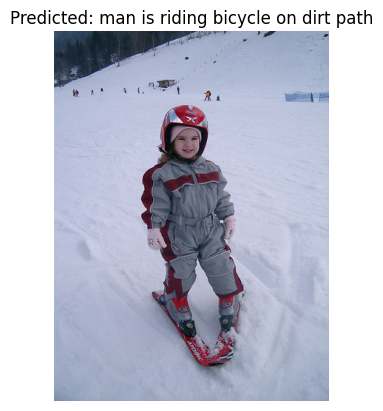

In [17]:
from PIL import Image
# Cell 12: Visualize Results (Using updated predict function)
def visualize_caption(image_name_vis, features_dict, mapping_dict, enc_model_inf, dec_model_inf, tokenizer_obj, max_cap_len, idx_to_word_mapping_dict):
    image_id_vis = image_name_vis.split('.')[0]
    
    if image_id_vis not in features_dict or image_id_vis not in mapping_dict:
        print(f"Error: Data for {image_id_vis} not found.")
        return

    img_path_vis = os.path.join(IMAGES_DIR, image_name_vis)
    try:
        image_pil = Image.open(img_path_vis)
    except FileNotFoundError:
        print(f"Error: Image file {img_path_vis} not found.")
        return

    actual_captions_vis = mapping_dict[image_id_vis]
    print(f"\n--- Image: {image_name_vis} ---")
    print('--- Actual Captions ---')
    for cap in actual_captions_vis:
        print(cap)
    
    predicted_caption_vis = predict_caption_simple_lstm(image_id_vis, features_dict, enc_model_inf, dec_model_inf, tokenizer_obj, max_cap_len, idx_to_word_mapping_dict)
    print('--- Predicted Caption ---')
    print(predicted_caption_vis)
    
    plt.imshow(image_pil)
    clean_predicted_for_title = predicted_caption_vis.replace('startseq','').replace('endseq','').strip()
    plt.title(f"Predicted: {clean_predicted_for_title[:80]}") # Limit title length
    plt.axis('off')
    plt.show()

# Visualize a few examples
if len(test_keys_usable) >= 3:
    print("\nVisualizing some results...")
    for i in range(min(3, len(test_keys_usable))): 
        example_id = test_keys_usable[i]
        example_img_name = example_id + ".jpg" 
        if os.path.exists(os.path.join(IMAGES_DIR, example_img_name)):
            visualize_caption(example_img_name, features, mapping, encoder_model_inf, decoder_model_inf, tokenizer, max_length, idx_to_word_map)
        else:
            print(f"Example image file not found: {example_img_name}")
else:
    print("Not enough test images for visualization.")